In [148]:
import matplotlib
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score


from sklearn.ensemble import RandomForestClassifier
from interpret.glassbox import ExplainableBoostingClassifier
import xgboost as xgb
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous,Categorical,Integer

from datetime import datetime

In [2]:
pd.set_option('display.max_columns',100)
df = pd.read_excel('Telco_customer_churn.xlsx')
#remove customerid,Count... as they won't help in prediction
df = df.drop(columns = ['CustomerID','Count','Zip Code','Churn Label','Churn Reason','Country','State','Lat Long','Churn Score'])

#City and location is ignored usually, So I am taking them out of the dataset
df = df.drop(columns = ['City','Latitude','Longitude'])
df = df.rename(columns = {'Churn Value' : 'Churn'})
print("number of rows and colums : " ,df.shape)
#place churn column at last
df = df.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,19]]


number of rows and colums :  (7043, 21)


In [3]:
#To get datatypes for all columns
df.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
CLTV                   int64
Churn                  int64
dtype: object

In [4]:
#Checking for missing values
df.isna().sum()
#None one of the attributes have null values !

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
CLTV                 0
Churn                0
dtype: int64

In [5]:
#Check for duplicated rows

df.duplicated().sum()
#None again , hurray!!
##for keep = first -> the first duplicated row will be false and other duplicated rows will be true. Vice-versa for last. 
df.duplicated(keep = 'first').sort_index()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [6]:
#Check for categorical column values
df['Contract'].nunique() # around 3 classes
df['Payment Method'].nunique() # around 4 classes
df['Dependents'].nunique()


2

GETTING TO KNOW THE TYPE OF PEOPLE WHO ARE CHURNING AND NOT CHURNING

Text(0.5, 1.0, 'Churn Distribution')

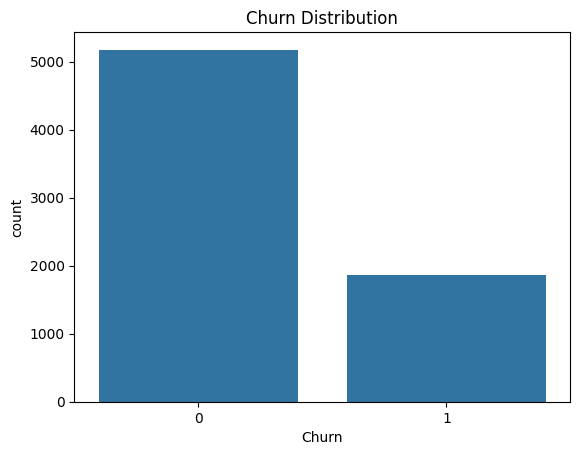

In [7]:
sns.countplot(data = df, x= 'Churn')
plt.title('Churn Distribution')

<Axes: xlabel='Contract', ylabel='count'>

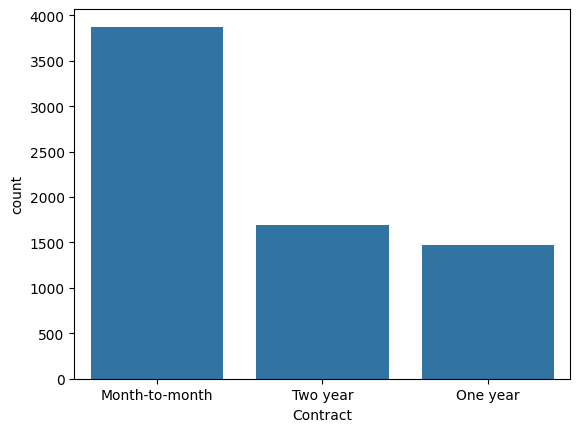

In [8]:
#Get the number of customers for each contract

sns.countplot(data = df ,x = 'Contract')


#This shows that number of people who use month-to-month is way higher than yearly contracts

<Axes: xlabel='Internet Service', ylabel='count'>

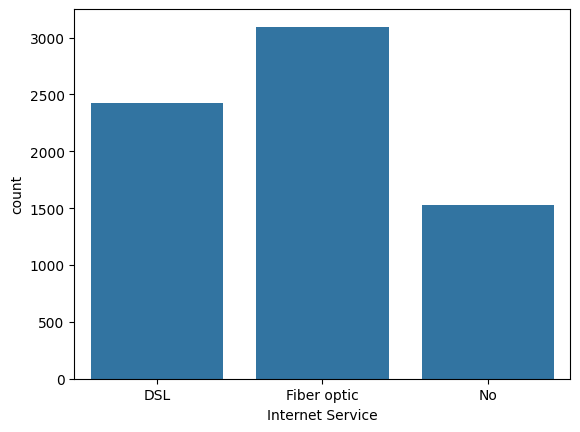

In [9]:
#Type of customers for each type of service

sns.countplot(data = df, x = 'Internet Service')

#People prefer Fiber optics more than DSL . 


<Axes: xlabel='Tenure Months', ylabel='Count'>

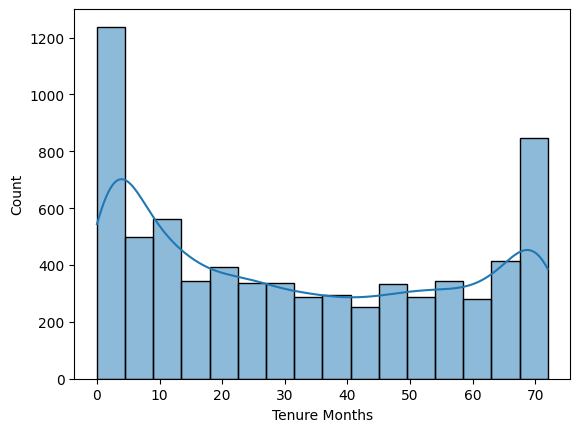

In [10]:
#Getting the tenure distribution to know the number of people who are staying with the company for a long time or short span of time.

sns.histplot(df['Tenure Months'],kde = True)

#It can be seen that the bar goes down rapidly between 0 and 5. Indicates that customers who are new have a higher chance of churning.
#In the middle ranges of tenure, the bars are at a consistent peak range.

<Axes: xlabel='Monthly Charges', ylabel='Count'>

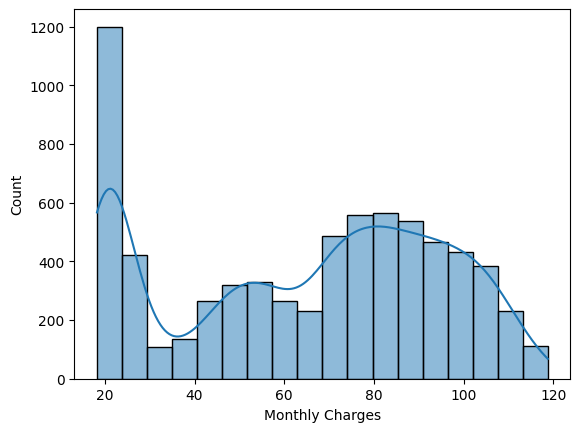

In [11]:
#How monthly Charges is distributed:
sns.histplot(df['Monthly Charges'],kde = True)
#Customers prefer low cost plans.
#Monthly charges around $80 and $100 is preferred on an average.

<Axes: xlabel='Contract', ylabel='count'>

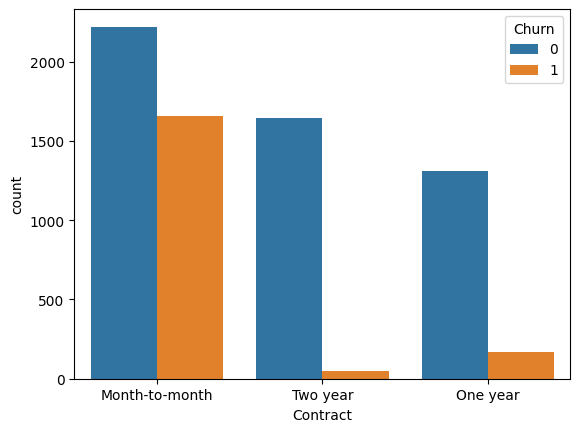

In [12]:
#How ContractTypes affect churn

sns.countplot(df, x = 'Contract',hue = 'Churn')

#Customers who buy month-month subscription have a high tendency to leave the company.

<Axes: xlabel='Internet Service', ylabel='count'>

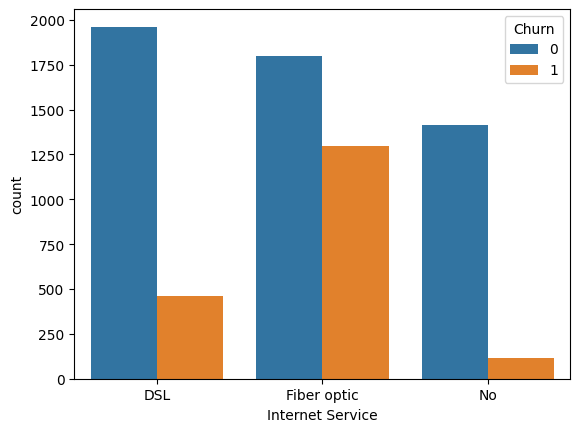

In [13]:
#How internet service affects churn

sns.countplot(df,x  = 'Internet Service', hue = 'Churn')

#Even though customers prefer Fiber Optic , they can still churn due to fiber optics.

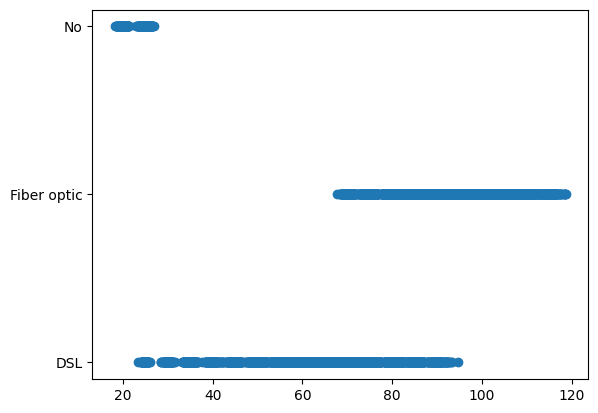

In [14]:
#How Internet affects Monthly Charges


plt.scatter(y = df['Internet Service'],x= df['Monthly Charges'])

#Fiber optics is quite expensive compared to dsl.

<Axes: xlabel='Churn', ylabel='Monthly Charges'>

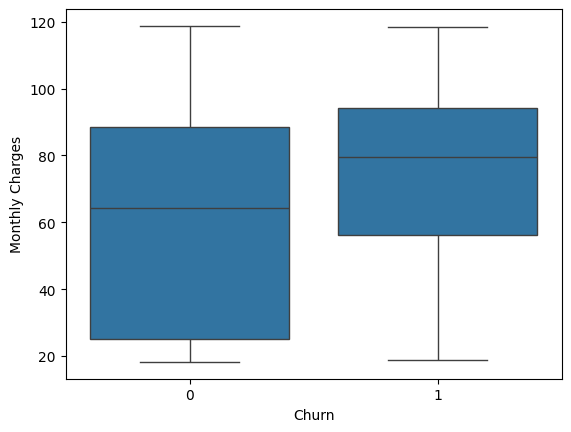

In [15]:
#Trying to understand if Monthly Charges is closely related to customer churn.

sns.boxplot(df,x = 'Churn',y = 'Monthly Charges')

#

<Axes: xlabel='Monthly Charges'>

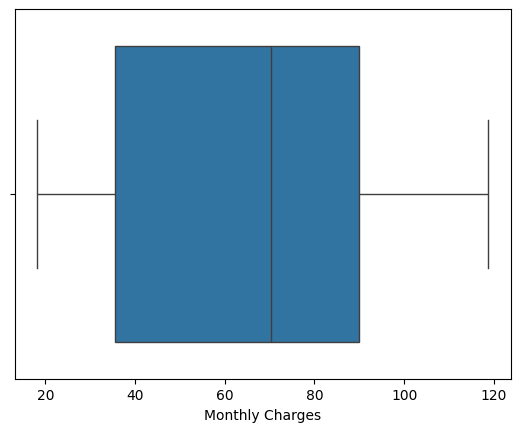

In [16]:
sns.boxplot(df,x = 'Monthly Charges')

#Monthly charges slightly skewed to the left.

<Axes: xlabel='Dependents', ylabel='count'>

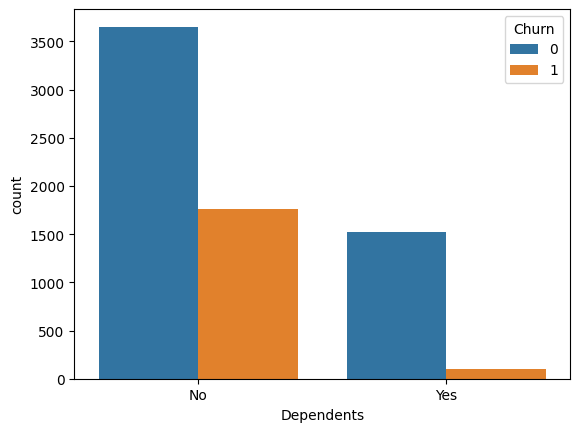

In [17]:
#Comparing churn and dependants
sns.countplot(df,x = 'Dependents' , hue  = 'Churn')

#People who have dependants are less likely to churn

<Axes: xlabel='Internet Service', ylabel='Monthly Charges'>

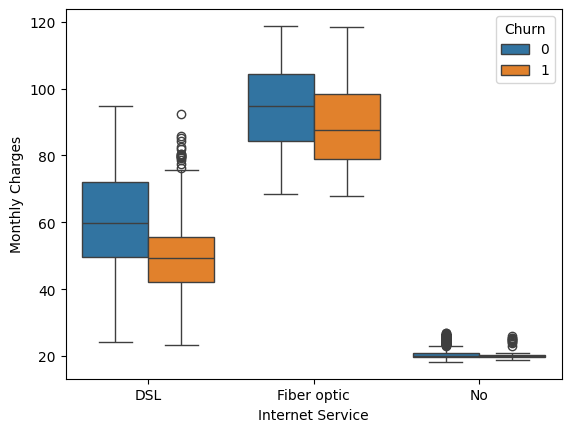

In [18]:
#Get to know how monlthly charges  affects churn for 3 types of internet services

sns.boxplot(df,x = 'Internet Service' , y ='Monthly Charges',hue = 'Churn')

<Axes: ylabel='count'>

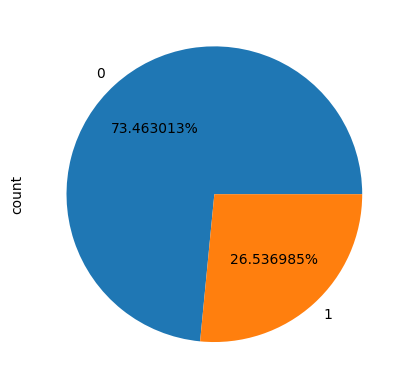

In [19]:
df['Churn'].value_counts().plot.pie(autopct = "%f%%")

Data conversion (Categorical to numeric) . 

In [35]:
df["Gender"].replace(['Male','Female'],[0,1],inplace=True)
df["Dependents"].replace(["Yes","No"],[1,0],inplace=True)
df["Partner"].replace(["Yes","No"],[1,0],inplace=True)
df["Senior Citizen"].replace(["Yes","No"],[1,0],inplace=True)
df["Phone Service"].replace(["Yes","No"],[1,0],inplace=True)
df["Multiple Lines"].replace(["No phone service"],["No"],inplace=True)
df["Multiple Lines"].replace(["Yes","No"],[1,0],inplace=True)
df['Paperless Billing'].replace(["Yes","No"],[1,0],inplace=True)

clean_rows = ['Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies']
for rows in clean_rows:
    df[rows].replace(["No internet service"],["No"],inplace=True)
    df[rows].replace(["Yes","No"],[1,0],inplace=True)



C:\Users\shrey\AppData\Local\Temp\ipykernel_9072\110979046.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].replace(['Male','Female'],[0,1],inplace=True)
C:\Users\shrey\AppData\Local\Temp\ipykernel_9072\110979046.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

One-Hot Encoding 


In [21]:
#Define one-hot encoder

# there are missing or unknown values in the column, sparse output refers to non-zero values, and transform the data for a pandas dataframe
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas') 
transformed_column = encoder.fit_transform(df[['Internet Service']])
df.drop(columns = ['Internet Service'])
df = pd.concat([df,transformed_column],axis = 1)
df['Internet Service_DSL'] = df['Internet Service_DSL'].astype(int)
df['Internet Service_No'] = df['Internet Service_No'].astype(int)
df['Internet Service_Fiber optic'] = df['Internet Service_Fiber optic'].astype(int)


payment_method_column = encoder.fit_transform(df[['Payment Method']])
df = pd.concat([df,payment_method_column],axis = 1).drop(columns = ['Payment Method','Internet Service'])
df['Payment Method_Bank transfer (automatic)'] = df['Payment Method_Bank transfer (automatic)'].astype(int)
df['Payment Method_Credit card (automatic)'] = df['Payment Method_Credit card (automatic)'].astype(int)
df['Payment Method_Electronic check'] = df['Payment Method_Electronic check'].astype(int)
df['Payment Method_Mailed check'] = df['Payment Method_Mailed check'].astype(int)

In [22]:
df.dtypes

Gender                                        int64
Senior Citizen                                int64
Partner                                       int64
Dependents                                    int64
Tenure Months                                 int64
Phone Service                                 int64
Multiple Lines                                int64
Online Security                               int64
Online Backup                                 int64
Device Protection                             int64
Tech Support                                  int64
Streaming TV                                  int64
Streaming Movies                              int64
Contract                                     object
Paperless Billing                             int64
Monthly Charges                             float64
Total Charges                                object
CLTV                                          int64
Churn                                         int64
Internet Ser

In [23]:
#Changing total charges from object type to numeric

df['Total Charges']= df['Total Charges'].replace(' ',0)
df['Total Charges'] = pd.to_numeric(df['Total Charges'])

C:\Users\shrey\AppData\Local\Temp\ipykernel_9072\2037112042.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total Charges']= df['Total Charges'].replace(' ',0)


In [24]:
df["Contract"].replace(['Month-to-month','One year','Two year'],[0,1,2],inplace=True)

C:\Users\shrey\AppData\Local\Temp\ipykernel_9072\1874680373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Contract"].replace(['Month-to-month','One year','Two year'],[0,1,2],inplace=True)
C:\Users\shrey\AppData\Local\Temp\ipykernel_9072\1874680373.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

Univariate Analysis is done on categorical variables (value counts is one of the analysis). This has been already done.
Moving onto Multivariate Analysis


In [25]:
#CLTV is not widely available in datasets
df  = df.drop(columns = ['CLTV'])
#New cltv attribute from eprofits
#Includes tenure from 0th month to ith month . Example : 2 months -> 3*monthly charges.
df['Customer Value'] = df['Monthly Charges']*df['Tenure Months'].apply(lambda x : x+1)
#Customer Value  is literally 99 % similar to Total Charges sooo droppin it
df = df.drop(columns=['Total Charges'])

<Axes: >

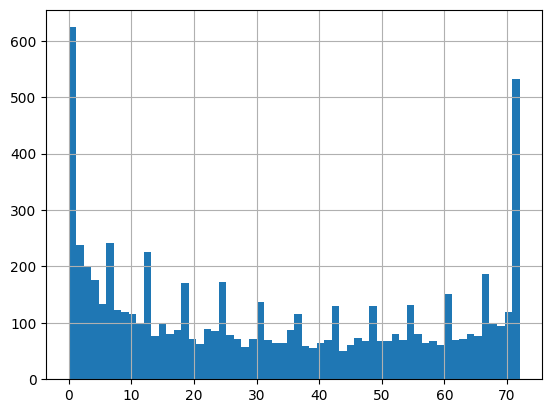

In [26]:
df['Tenure Months'].hist(bins=60)
#Tenure Data is skewed on the left side (positively skewed).

<Axes: xlabel='Customer Value'>

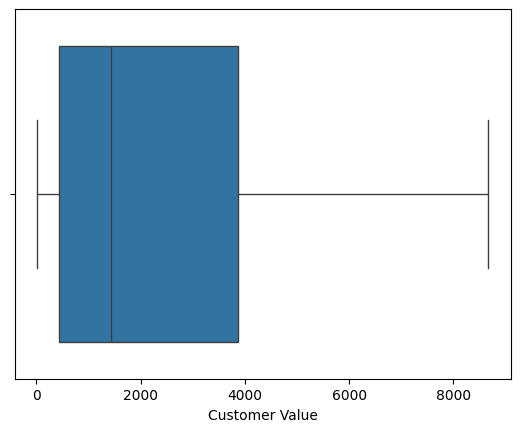

In [27]:
sns.boxplot(x=df['Customer Value'])

In [28]:
#Check for correlated columns.
df.columns

dfcorr = df[['Tenure Months','Monthly Charges', 'Customer Value']].corr()

In [29]:
dfcorr
#As you can see, Total charges ,monthly charges, Tenure Months are heavily related

,Tenure Months,Monthly Charges,Customer Value
Tenure Months,1.000000,0.247900,0.822698
Monthly Charges,0.247900,1.000000,0.659114
Customer Value,0.822698,0.659114,1.000000


<Axes: >

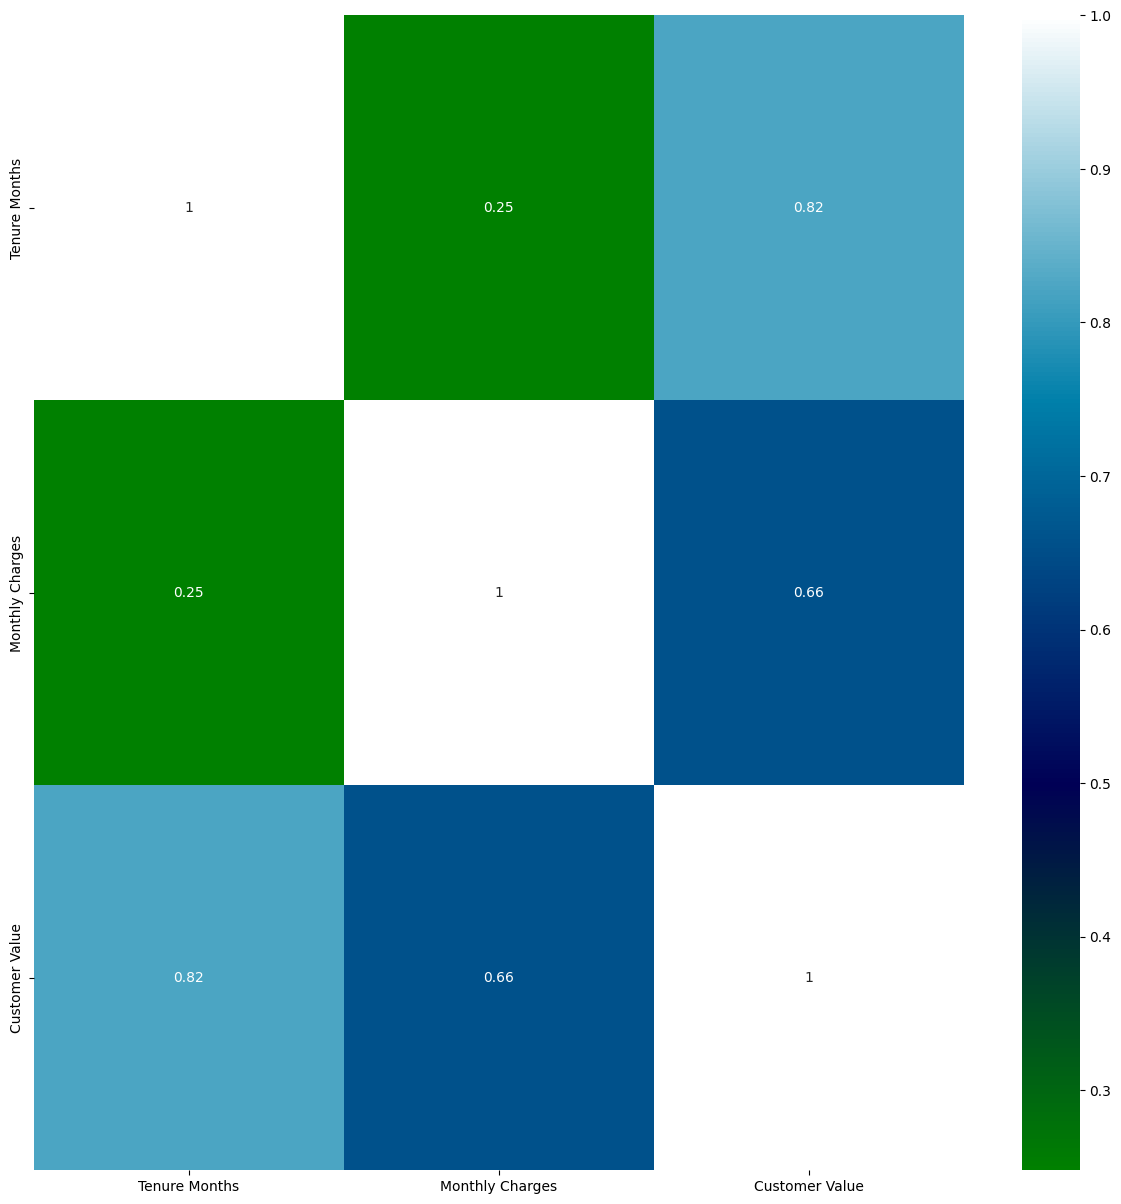

In [30]:
#heatmap for checking correlation


fig,ax = plt.subplots(figsize=(15,15)) #This is to set the plot size, not required for the actual data plotting but for setting size or window size.
sns.heatmap(dfcorr,annot=True,cmap= 'ocean')

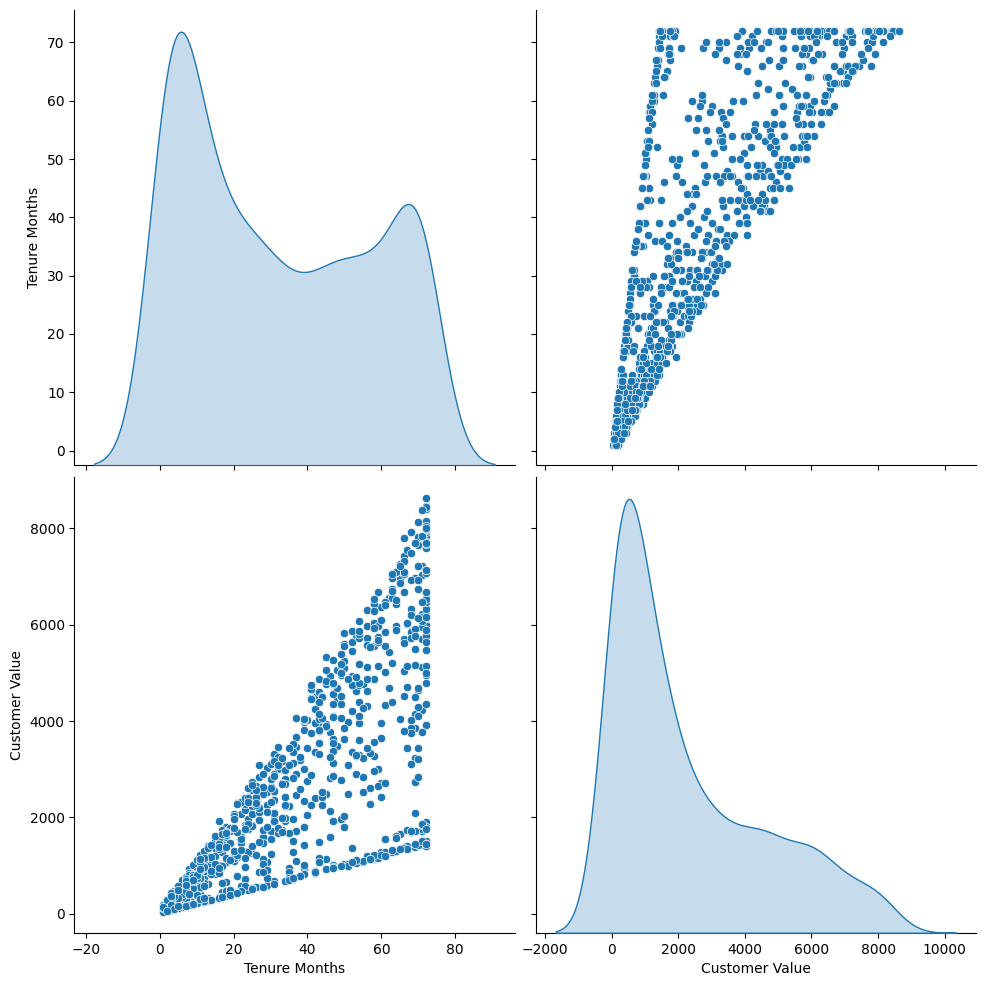

In [31]:
#Now we move on to pair plots and understand correlation between two features
dfsample = df.sample(n=1000)
sns.pairplot(dfsample[['Tenure Months','Customer Value']],height = 5,aspect=1,diag_kind= 'kde')

Feature Engineering


In [32]:
x = df.drop(columns = 'Churn')
y  = df['Churn']
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
important_features = rfc.feature_importances_

In [113]:
names_of_columns = x.columns
named_important_features = pd.DataFrame({'Feature': x.columns , 'importance' : important_features})
sorted_named_important_features = named_important_features.sort_values(by = 'importance', ascending= False)
print(sorted_named_important_features)

                                     Feature  importance
23                            Customer Value    0.183541
15                           Monthly Charges    0.172748
4                              Tenure Months    0.156265
13                                  Contract    0.084909
17              Internet Service_Fiber optic    0.039221
3                                 Dependents    0.035921
21           Payment Method_Electronic check    0.033382
0                                     Gender    0.027424
2                                    Partner    0.025668
14                         Paperless Billing    0.025024
1                             Senior Citizen    0.021033
7                            Online Security    0.020549
8                              Online Backup    0.020528
10                              Tech Support    0.020433
6                             Multiple Lines    0.019111
9                          Device Protection    0.018580
12                          Str

This is the number of coulmns :  24


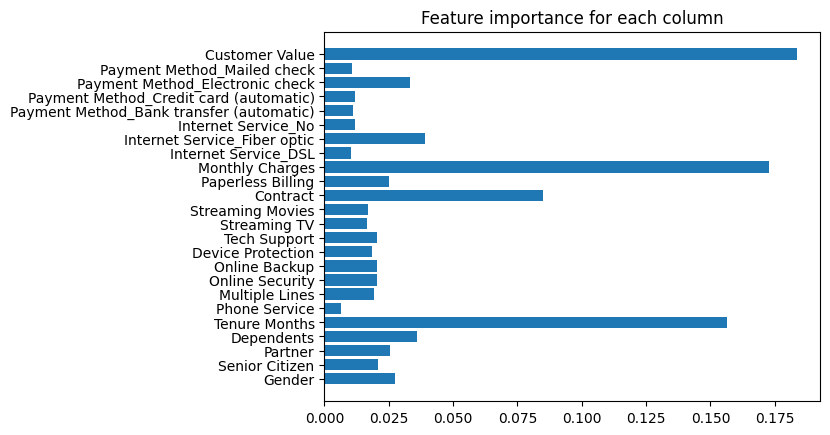

In [114]:
print("This is the number of coulmns : " , x.shape[1])
plt.plot()
plt.barh(range(x.shape[1]),width = important_features)
plt.yticks(range(x.shape[1]),x.columns.to_list())
plt.title("Feature importance for each column")
plt.show()

In [146]:
#I have chose to select only 20 features out of 24.

top_20_features = sorted_named_important_features['Feature'][:20].values

new_x = x[top_20_features]

x_train, x_test, y_train, y_test = train_test_split(new_x, y, test_size=.3, random_state=42)
tenure_column = 'Tenure Months'

EPROFITS FUNCTION

(4930,) (4930,)


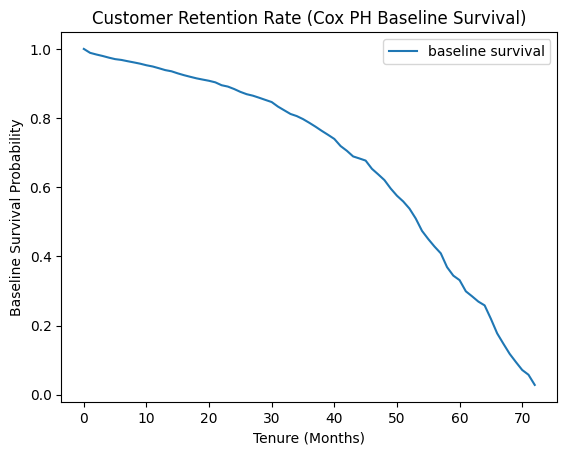

ARR(Δ=1.0): 0.956063
0.9527499999990026


In [149]:
# ===================== IMPORTS =====================
from lifelines import CoxPHFitter
from EMP.metrics import empChurn
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np
import warnings

# ===================== CUSTOM METRICS =====================
# Survival Analysis: Cox Proportional Hazards model used to model time-to-churn and estimate retention.

def conditional_retention(retention_fn, tenure, delta=1.0, eps=1e-12):
    ten = np.asarray(tenure, dtype=float)
    S_t = np.asarray(retention_fn(ten), dtype=float)
    S_t_delta = np.asarray(retention_fn(ten + delta), dtype=float)
    return S_t_delta / np.maximum(S_t, eps)


def get_retention_rate(x_train, y_train, tenure_column, delta=1.0):
    tenure = x_train[tenure_column].values.astype(float)
    event_observed = (y_train == 1).astype(int).values

    print(tenure.shape, event_observed.shape)

    cox_df = x_train.copy()
    cox_df["_duration"] = tenure
    cox_df["_event"] = event_observed

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(
        cox_df,
        duration_col="_duration",
        event_col="_event"
    )

    cph.baseline_survival_.plot()
    plt.title("Customer Retention Rate (Cox PH Baseline Survival)")
    plt.xlabel("Tenure (Months)")
    plt.ylabel("Baseline Survival Probability")
    plt.show()

    baseline_sf = cph.baseline_survival_

    def S(t):
        t_arr = np.atleast_1d(np.asarray(t, dtype=float))
        vals = []

        for ti in t_arr:
            idx = baseline_sf.index.searchsorted(ti, side="right") - 1
            idx = max(0, min(idx, len(baseline_sf) - 1))
            vals.append(float(baseline_sf.iloc[idx, 0]))

        vals = np.array(vals)
        return float(vals[0]) if np.isscalar(t) else vals

    trr_train = conditional_retention(S, tenure, delta=delta)
    arr_train = float(np.mean(trr_train))

    print(f'ARR(Δ={delta}): {arr_train:.6f}')
    return arr_train, S


# --- Preserve your variable names exactly ---
DELTA = 1.0
avg_retention_rate, retention_fn = get_retention_rate(
    x_train,
    y_train,
    tenure_column,
    delta=DELTA
)

print(retention_fn(10))
f'Average Retention Rate {avg_retention_rate: .2f}'


def estimate_clv_and_cost_of_intervention(df, i, Profit_Margin=0.3, CPO=0.1):
    monthly_revenue = df.iloc[i]['customer_value']
    retention_rate = min(0.995, df.iloc[i]['retention_rate'])
    clv = (monthly_revenue * Profit_Margin) / (1 - retention_rate)

    base_cost = CPO * clv
    cost_per_offer = base_cost

    return clv, cost_per_offer


def _eprofits(df, Profit_Margin, Cost_of_Contact, CPO, verbose=0):
    profits = []

    for i in range(len(df)):
        clv, cost_per_offer = estimate_clv_and_cost_of_intervention(
            df,
            i,
            Profit_Margin,
            CPO
        )

        cost_of_contact = max(
            Cost_of_Contact[0],
            Cost_of_Contact[1] * cost_per_offer
        )

        if df.iloc[i]['true'] == 1 and df.iloc[i]['predict'] == df.iloc[i]['true']:
            profit = clv - cost_per_offer - cost_of_contact

            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        elif df.iloc[i]['predict'] == 1:
            profit = -cost_per_offer - cost_of_contact

            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        else:
            profit = 0

        profits.append(profit)

    return sum(profits)


Profit_Margin = 0.3
Cost_of_Contact = (0, 0.3)
CPO = 0.1


def custom_eprofits_scorer_tenure(
    df,
    tenure_column,
    retention_fn,
    delta,
    Profit_Margin,
    Cost_of_Contact,
    CPO,
    threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        ten = my_df[tenure_column].astype(float).values
        my_df["retention_rate"] = conditional_retention(
            retention_fn,
            ten,
            delta=delta
        )

        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred

        return _eprofits(
            my_df,
            Profit_Margin,
            Cost_of_Contact,
            CPO
        )

    return scorer


def custom_eprofits_scorer_avg(
    df,
    avg_retention_rate,
    Profit_Margin,
    Cost_of_Contact,
    CPO,
    threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        my_df["retention_rate"] = float(avg_retention_rate)
        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred

        return _eprofits(
            my_df,
            Profit_Margin,
            Cost_of_Contact,
            CPO
        )

    return scorer


def emp_scorer(estimator, X, y):
    y_proba = estimator.predict_proba(X)[:, 1]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        with np.errstate(divide="ignore", invalid="ignore"):
            return empChurn(
                y_proba,
                y,
                alpha=6,
                beta=14,
                clv=200,
                d=10,
                f=1,
                print_output=False,
                return_output=True,
                rounding=None
            ).EMP


eprofits_scorer_train_tenure = custom_eprofits_scorer_tenure(
    df=x_train,
    tenure_column=tenure_column,
    retention_fn=retention_fn,
    delta=DELTA,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

eprofits_scorer_train_avg = custom_eprofits_scorer_avg(
    df=x_train,
    avg_retention_rate=avg_retention_rate,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

MODEL BUILDING , TRAINING , RESULTS

In [141]:
#Setting cross validation number 
cv = 5


In [ ]:
#Importing models into variables
random_state = 42
ebm = ExplainableBoostingClassifier(random_state=random_state)
xgb = xgb.XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='logloss')
rf = RandomForestClassifier(random_state=random_state)


#Setting each  model's parameter grid

param_grid_rf = {
    'n_estimators': Integer(100, 200, 300),
    'max_depth': Integer(0,10, 20, 30),
    'min_samples_split': Integer(2, 5, 10),
    'min_samples_leaf': Integer(1, 2, 4)
}


param_grid_ebm = {
    'learning_rate': Continuous(0.01,0.1),
    'max_bins': Integer(128,256),
    'max_interaction_bins': Integer(16,32),
    'interactions': Integer(10,20)
}
   
param_grid_xgb = {
    'n_estimators': Integer(100,300),
    'learning_rate': Continuous(0.01, 0.2),
    'max_depth': Integer(3, 5),
    'colsample_bytree': Continuous(0.3, 0.7)
}


#Storing each model's parameters into a list for genetic search 
Classifiers_with_grids = [
    (rf, param_grid_rf, 'rf'),
    (ebm, param_grid_ebm, 'ebm'),
    (xgb, param_grid_xgb, 'xgb'),
]

#Metrics to train models on 

Metrics_to_hypertune_for = {
   "AUC": 'roc_auc',
    "accuracy": metrics.make_scorer(metrics.accuracy_score),
    "f1": metrics.make_scorer(metrics.f1_score),
    "emp": emp_scorer,
    "eprofits_avg": eprofits_scorer_train_avg,
    "eprofits_tenure": eprofits_scorer_train_tenure,
}

#Genetic search algorithm that runs for every model
def genetic_search(model, param_grid, x, y, cv, scoring, refit=True, verbose=None, _name=None):
    if refit == 'emp':
        n_jobs = 1
    else:
        n_jobs = -1
    now = datetime.datetime.now()
    if _name:
        print(_name.title(), 'at', now)
    else:
        print('At', now)
    start = datetime.time()

    if verbose:

        #Generally , pop size is more than generations. More population leads to more solutions .
        gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=20,generations=10,tournament_size=3,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.2,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs, verbose=verbose,keep_top_k=2)
    
    else:

        gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=20,generations=10,tournament_size=3,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.2,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs,keep_top_k=2)
    gs.fit(x, y)
    taken = datetime.time() - start
    gs.fit_time_ = taken  # Creating a custom object for grid search known as fit_time_
    print(f' > done; taken {taken:.2f}')
    return gs

genetic_search_results = {}



#This function is used for training every classifier on each metric (Standard metrics and eprofits)
def genetic_search_driver(Metrics_to_hypertune_for):
    for Metric_name, Metric_function in Metrics_to_hypertune_for.items():
        _scoring = {Metric_name: Metric_function}
        refit = Metric_name

        print('With scoring', Metric_name)
        for classifier, param_grid, name_of_model in Classifiers_with_grids:
            if name_of_model not in genetic_search_results:
                genetic_search_results[name_of_model] = {}
            genetic_search_results[name_of_model][Metric_name] = genetic_search(
                classifier, param_grid, x_train, y_train, cv, _scoring, refit, verbose=1, _name=name_of_model
            )
    return genetic_search_results

genetic_search_results = genetic_search_driver(Metrics_to_hypertune_for)




GETTING RESULTS


In [ ]:
import numpy as np
import pandas as pd
from sklearn import metrics
from scipy import stats

#RF RESULTS:


rf_y_pred = genetic_search_results['rf']['eprofits_tenure'].predict(x_test)
rf_y_scores = genetic_search_results['rf']['eprofits_tenure'].predict_proba(x_test)[:,1]

rf_accuracy = metrics.accuracy_score(rf_y_pred,y_test)
rf_f1 = metrics.f1_score(rf_y_pred,rf_y_pred)
rf_auc = metrics.roc_auc_score(y_test,rf_y_scores)

rf_df = x_test.loc[y_test.index].copy()
rf_df["retention_rate"] = conditional_retention(
    retention_fn,
    rf_df[tenure_column].astype(float).values,
    delta=DELTA
)
rf_df["true"] = np.asarray(y_test)
rf_df["predict"] = rf_y_pred

rf_eprofits = _eprofits(
    rf_df,
    Profit_Margin,
    Cost_of_Contact,
    CPO
)

rf_emp = empChurn(
    rf_y_scores,
    y_test,
    alpha=6,
    beta=14,
    clv=200,
    d=10,
    f=1,
    print_output=False,
    return_output=True,
    rounding=None
).EMP

print("Scores for Random Forest")
print(f"accuracy score : {rf_accuracy} ,f1 : {rf_f1} , auc : {rf_auc}")
print(f"eprofits : {rf_eprofits} , emp : {rf_emp}")


#XGBOOST RESULTS :

xg_boost_y_pred = genetic_search_results['xgb']['eprofits_tenure'].predict(x_test)
xg_boost_y_scores = genetic_search_results['xgb']['eprofits_tenure'].predict_proba(x_test)[:,1]

xg_boost_accuracy = metrics.accuracy_score(xg_boost_y_pred,y_test)
xg_boost_f1 = metrics.f1_score(xg_boost_y_pred,xg_boost_y_pred)
xg_boost_auc = metrics.roc_auc_score(y_test,xg_boost_y_scores)

xgb_df = x_test.loc[y_test.index].copy()
xgb_df["retention_rate"] = conditional_retention(
    retention_fn,
    xgb_df[tenure_column].astype(float).values,
    delta=DELTA
)
xgb_df["true"] = np.asarray(y_test)
xgb_df["predict"] = xg_boost_y_pred

xgb_eprofits = _eprofits(
    xgb_df,
    Profit_Margin,
    Cost_of_Contact,
    CPO
)

xgb_emp = empChurn(
    xg_boost_y_scores,
    y_test,
    alpha=6,
    beta=14,
    clv=200,
    d=10,
    f=1,
    print_output=False,
    return_output=True,
    rounding=None
).EMP

print("Scores for xgboost ")
print(f"accuracy score : {xg_boost_accuracy} ,f1 : {xg_boost_f1} , auc : {xg_boost_auc}")
print(f"eprofits : {xgb_eprofits} , emp : {xgb_emp}")


#EBM RESULTS:

y_pred = genetic_search_results['ebm']['eprofits_tenure'].predict(x_test)
y_scores = genetic_search_results['ebm']['eprofits_tenure'].predict_proba(x_test)[:,1]

accuracy = metrics.accuracy_score(y_pred,y_test)
f1 = metrics.f1_score(y_test,y_pred)
auc = metrics.roc_auc_score(y_test,y_scores)

ebm_df = x_test.loc[y_test.index].copy()
ebm_df["retention_rate"] = conditional_retention(
    retention_fn,
    ebm_df[tenure_column].astype(float).values,
    delta=DELTA
)
ebm_df["true"] = np.asarray(y_test)
ebm_df["predict"] = y_pred

ebm_eprofits = _eprofits(
    ebm_df,
    Profit_Margin,
    Cost_of_Contact,
    CPO
)

ebm_emp = empChurn(
    y_scores,
    y_test,
    alpha=6,
    beta=14,
    clv=200,
    d=10,
    f=1,
    print_output=False,
    return_output=True,
    rounding=None
).EMP

print("ebm scores")
print(f"accuracy score : {accuracy} , f1 : {f1}, auc : {auc}")
print(f"eprofits : {ebm_eprofits} , emp : {ebm_emp}")